# Pet Store Transactions Analysis: Uncovering Sales Insights with Python

Author: Charlene D'Costa <br />
Date: February 10, 2025 <br />
Coursework for the Meta Marketing Analytics Professional Certificate. <br />

[Pet Store Transactions Dataset](need to upload)

# Project Overview

For this project, I used Python to perform data cleaning and exploratory data analysis (EDA) on a fictitious pet store transactions dataset. I began by cleaning the data—handling missing values, removing data anomalies, and dropping columns with excessive nulls. Next, I conducted EDA to uncover product sales trends, analyze the quantity sold by category, and identify both the most popular and the highest-priced categories within different product lines. Finally, I created visualizations, including bar and box plots, to provide stakeholders with actionable insights on top-selling categories and price distributions, informing business decisions about which product lines drive the most revenue and where pricing adjustments might be considered.

# Data Cleaning

In this section, I will import and clean the dataset to prepare it for analysis. I will use PyCharm as my integrated development environment (IDE) along with its Jupyter Notebook integration to perform the analysis. Additionally, I import the following libraries, which will be used throughout the project: pandas, matplotlib, and seaborn.

In [20]:
# Importing libraries.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing dataset.
df = pd.read_csv("./data/transactions.csv")

,Date,Order_Number,Customer_ID,Product_Name,SKU,Price,Size,Quantity,Product_Category,Product_Line
0,5/22/2021,SXF-7309-1727-1334,476582ea-1bba-4289-8775-3fcd8074821c,Feline Fix Mix,RKAPY3I1TP,39.55,NaN,1,treat,cat
1,5/22/2021,SXF-7309-1727-1334,476582ea-1bba-4289-8775-3fcd8074821c,Scratchy Post,MPH6SCD7UT,26.95,NaN,3,toy,cat
2,5/22/2021,SXF-7309-1727-1334,476582ea-1bba-4289-8775-3fcd8074821c,Reddy Beddy,DJWE1V9LZK,23.07,large,3,bedding,dog
3,3/23/2020,DG7-5410-5845-1340,5929a0e9-95a7-4dbf-896e-c11d1988615e,Snoozer Essentails,GABWVMEL2R,28.04,NaN,3,bedding,dog
4,3/23/2020,DG7-5410-5845-1340,5929a0e9-95a7-4dbf-896e-c11d1988615e,Reddy Beddy,KDTMPSBZKZ,13.84,small,1,bedding,dog
...,...,...,...,...,...,...,...,...,...,...
2898,10/16/2020,P8K-8079-0264-6569,468f40b3-59ca-47fd-9739-c7f19cf48f32,Cat Cave,058G0P7V60,29.66,NaN,1,bedding,cat
2899,10/16/2020,P8K-8079-0264-6569,468f40b3-59ca-47fd-9739-c7f19cf48f32,Kitty Climber,W86BRJ9SSG,39.32,NaN,1,toy,cat
2900,10/16/2020,P8K-8079-0264-6569,468f40b3-59ca-47fd-9739-c7f19cf48f32,Fetch Blaster,M291KHJ4LW,29.47,NaN,1,toy,dog
2901,10/16/2020,P8K-8079-0264-6569,468f40b3-59ca-47fd-9739-c7f19cf48f32,Snoozer Essentails,GABWVMEL2R,28.04,NaN,1,bedding,dog


In [29]:
# Using df.info() to display a concise summary of the DataFrame, including the index, column names, data types, non-null counts, and memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2758 entries, 0 to 2902
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              2758 non-null   object 
 1   Order_Number      2758 non-null   object 
 2   Customer_ID       2716 non-null   object 
 3   Product_Name      2758 non-null   object 
 4   SKU               2758 non-null   object 
 5   Price             2758 non-null   float64
 6   Size              626 non-null    object 
 7   Quantity          2758 non-null   int64  
 8   Product_Category  2758 non-null   object 
 9   Product_Line      2758 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 237.0+ KB


### Question 1: Remove all rows that are missing either the `Product_Name` or the `Product_Category`.

In [28]:
# Dropping rows where either the 'Product_Name' or the 'Product_Category' column has a missing value.
df = df.dropna(subset = ['Product_Name', 'Product_Category'])

,Date,Order_Number,Customer_ID,Product_Name,SKU,Price,Size,Quantity,Product_Category,Product_Line
0,5/22/2021,SXF-7309-1727-1334,476582ea-1bba-4289-8775-3fcd8074821c,Feline Fix Mix,RKAPY3I1TP,39.55,NaN,1,treat,cat
1,5/22/2021,SXF-7309-1727-1334,476582ea-1bba-4289-8775-3fcd8074821c,Scratchy Post,MPH6SCD7UT,26.95,NaN,3,toy,cat
2,5/22/2021,SXF-7309-1727-1334,476582ea-1bba-4289-8775-3fcd8074821c,Reddy Beddy,DJWE1V9LZK,23.07,large,3,bedding,dog
3,3/23/2020,DG7-5410-5845-1340,5929a0e9-95a7-4dbf-896e-c11d1988615e,Snoozer Essentails,GABWVMEL2R,28.04,NaN,3,bedding,dog
4,3/23/2020,DG7-5410-5845-1340,5929a0e9-95a7-4dbf-896e-c11d1988615e,Reddy Beddy,KDTMPSBZKZ,13.84,small,1,bedding,dog
...,...,...,...,...,...,...,...,...,...,...
2898,10/16/2020,P8K-8079-0264-6569,468f40b3-59ca-47fd-9739-c7f19cf48f32,Cat Cave,058G0P7V60,29.66,NaN,1,bedding,cat
2899,10/16/2020,P8K-8079-0264-6569,468f40b3-59ca-47fd-9739-c7f19cf48f32,Kitty Climber,W86BRJ9SSG,39.32,NaN,1,toy,cat
2900,10/16/2020,P8K-8079-0264-6569,468f40b3-59ca-47fd-9739-c7f19cf48f32,Fetch Blaster,M291KHJ4LW,29.47,NaN,1,toy,dog
2901,10/16/2020,P8K-8079-0264-6569,468f40b3-59ca-47fd-9739-c7f19cf48f32,Snoozer Essentails,GABWVMEL2R,28.04,NaN,1,bedding,dog


### Question 2: Find any clearly "incorrect" values in the `Price` column and clean the DataFrame to address those values.

In [32]:
# Based on the earlier output from df.info(), we know that the 'Price' column is numeric (float64).
# Therefore, instead of checking for non-numeric data, we need to verify that the price values are valid.
# For example, negative prices are not acceptable.

# Check the minimum and maximum values of the 'Price' column.
# (A negative minimum indicates an invalid value.)
df.Price.min(), df.Price.max()

# Create a mask to retain only rows where 'Price' is greater than 0 and less than 15,000.
# This filters out any negative prices and any values that are unreasonably high.
valid_mask = (df.Price > 0) & (df.Price < 15000)

# Apply the mask to filter the DataFrame.
df = df[valid_mask]

(np.float64(10.8), np.float64(39.55))

### Question 3: After you've done the cleaning above, remove any column that has more than 500 missing values.

In [33]:
# From counting the number of missing values in each column, we see that the 'Size' column has over 500 missing values (2222 missing values).
df.isna().sum()

# Dropping the 'Size' column from the DataFrame.
df = df.drop(columns='Size')

### Question 4: Address the other missing values. You can replace the values or remove them, but whatever method you decide to clean the DataFrame, you should no longer have any missing values.

In [35]:
# Using df.dropna() to remove any remaining rows that contain missing values.
df = df.dropna()

# Verifying that all missing values have been removed by counting the missing values in each column. Since there are none, we can move on.
df.isna().sum()

Date                0
Order_Number        0
Customer_ID         0
Product_Name        0
SKU                 0
Price               0
Quantity            0
Product_Category    0
Product_Line        0
dtype: int64

# Exploratory Data Analysis

### Question 5: Create a `Subtotal` column by multiplying the `Price` and `Quantity` values.

In [36]:
# Creating 'Subtotal' column
df['Subtotal'] = df.Price * df.Quantity

,Date,Order_Number,Customer_ID,Product_Name,SKU,Price,Quantity,Product_Category,Product_Line,Subtotal
0,5/22/2021,SXF-7309-1727-1334,476582ea-1bba-4289-8775-3fcd8074821c,Feline Fix Mix,RKAPY3I1TP,39.55,1,treat,cat,39.55
1,5/22/2021,SXF-7309-1727-1334,476582ea-1bba-4289-8775-3fcd8074821c,Scratchy Post,MPH6SCD7UT,26.95,3,toy,cat,80.85
2,5/22/2021,SXF-7309-1727-1334,476582ea-1bba-4289-8775-3fcd8074821c,Reddy Beddy,DJWE1V9LZK,23.07,3,bedding,dog,69.21
3,3/23/2020,DG7-5410-5845-1340,5929a0e9-95a7-4dbf-896e-c11d1988615e,Snoozer Essentails,GABWVMEL2R,28.04,3,bedding,dog,84.12
4,3/23/2020,DG7-5410-5845-1340,5929a0e9-95a7-4dbf-896e-c11d1988615e,Reddy Beddy,KDTMPSBZKZ,13.84,1,bedding,dog,13.84
...,...,...,...,...,...,...,...,...,...,...
2898,10/16/2020,P8K-8079-0264-6569,468f40b3-59ca-47fd-9739-c7f19cf48f32,Cat Cave,058G0P7V60,29.66,1,bedding,cat,29.66
2899,10/16/2020,P8K-8079-0264-6569,468f40b3-59ca-47fd-9739-c7f19cf48f32,Kitty Climber,W86BRJ9SSG,39.32,1,toy,cat,39.32
2900,10/16/2020,P8K-8079-0264-6569,468f40b3-59ca-47fd-9739-c7f19cf48f32,Fetch Blaster,M291KHJ4LW,29.47,1,toy,dog,29.47
2901,10/16/2020,P8K-8079-0264-6569,468f40b3-59ca-47fd-9739-c7f19cf48f32,Snoozer Essentails,GABWVMEL2R,28.04,1,bedding,dog,28.04


### Question 6: Identify the most common `Product_Category` purchased for each `Product_Line`. Then, assign the name of that category (as a string) to the variables common_category_cat and common_category_dog.

In [37]:
# Grouping the DataFrame by 'Product_Line' and 'Product_Category' and summing the numeric columns (e.g., Quantity) to identify the most purchased item for each Product Line (cat and dog).
df.groupby(['Product_Line', 'Product_Category']).sum()

# Based on the aggregated results, assigning the most common product category (i.e., the one with the highest total items sold) for each product line to the respective variables.
common_category_cat = 'treat'
common_category_dog = 'bedding'

Date  \
Product_Line Product_Category                                                      
cat          bedding           9/21/20199/12/20209/14/20198/24/202111/6/20197...   
             food              6/30/20219/14/20191/27/202010/9/20198/24/20217...   
             toy               5/22/20215/14/20209/12/20205/30/20219/14/20191...   
             treat             5/22/20211/5/20205/14/202011/2/202012/2/20191/...   
dog          bedding           5/22/20213/23/20203/23/20205/16/20215/14/20209...   
             food              3/23/20205/14/20209/12/20205/30/20219/26/20203...   
             toy               1/5/20201/5/20206/30/20216/22/20217/25/20219/2...   
             treat             9/21/20199/14/20195/27/20217/7/20204/3/20195/2...   

                                                                    Order_Number  \
Product_Line Product_Category                                                      
cat          bedding           ENT-5271-0660-48509K8-5765-4461-7159G7Y-9331-8...   
             food              TCS-6223-7628-2720G7Y-9331-8313-29499FH-9267-0...   
             toy               SXF-7309-1727-1334VQE-2656-9729-61949K8-5765-4...   
             treat             SXF-7309-1727-133414C-6286-0019-4676VQE-2656-9...   
dog          bedding           SXF-7309-1727-1334DG7-5410-5845-1340DG7-5410-5...   
             food              DG7-5410-5845-1340VQE-2656-9729-61949K8-5765-4...   
             toy               14C-6286-0019-467614C-6286-0019-4676TCS-6223-7...   
             treat             ENT-5271-0660-4850G7Y-9331-8313-2949R3O-6541-4...   

                                                                     Customer_ID  \
Product_Line Product_Category                                                      
cat          bedding           d13c8860-67ae-44fb-8827-7afa9b4eec7a5c91c913-6...   
             food              aacbf226-43d2-4b06-987b-5c4224c11b9d5bc15bf9-0...   
             toy               476582ea-1bba-4289-8775-3fcd8074821c041686b3-e...   
             treat             476582ea-1bba-4289-8775-3fcd8074821ce7b79f56-2...   
dog          bedding           476582ea-1bba-4289-8775-3fcd8074821c5929a0e9-9...   
             food              5929a0e9-95a7-4dbf-896e-c11d1988615e041686b3-e...   
             toy               e7b79f56-2196-49a0-852a-3d329ad7cb57e7b79f56-2...   
             treat             d13c8860-67ae-44fb-8827-7afa9b4eec7a5bc15bf9-0...   

                                                                    Product_Name  \
Product_Line Product_Category                                                      
cat          bedding           Cat CaveSnoozer HammockSnoozer HammockCat Cave...   
             food              Yum Fish-DishPurr MixYum Fish-DishPurr MixYum ...   
             toy               Scratchy PostFoozy MouseFoozy MouseFoozy Mouse...   
             treat             Feline Fix MixSnack-em FishFeline Fix MixPurrf...   
dog          bedding           Reddy BeddySnoozer EssentailsReddy BeddyReddy ...   
             food              Whole Chemistry RecipeWhole Chemistry RecipeWh...   
             toy               Tug-a-BackChomp-a PlushFetch BlasterChomp-a Pl...   
             treat             Chewie DentalChewie DentalAll Veggie YummiesAl...   

                                                                             SKU  \
Product_Line Product_Category                                                      
cat          bedding           058G0P7V60V4B4RNS3ZPV4B4RNS3ZP058G0P7V60058G0P...   
             food              GZCJZ3ET04O5FYJLBE0HGZCJZ3ET04O5FYJLBE0HGZCJZ3...   
             toy               MPH6SCD7UT8PYSMLYINS8PYSMLYINS8PYSMLYINS8PYSML...   
             treat             RKAPY3I1TPORGRBTIKZRRKAPY3I1TP28LQOI0LSKA8SU9C...   
dog          bedding           DJWE1V9LZKGABWVMEL2RKDTMPSBZKZDJWE1V9LZKI2GQUN...   
             food              6K4AUUS7306K4AUUS7306K4AUUS730NYW2F6CPBY6K4AUU...   
             toy               IZBHF5KR7

### Question 7: Determine which categories (`Product_Category`) by `Product_Line` have the median highest `Price`. Assign the (string) name of these categories to their respective variables priciest_category_cat and priciest_category_dog.

In [38]:
# Grouping the DataFrame by 'Product_Line' and 'Product_Category' and calculating the median 'Price' for each group to identify which product category has the highest median price within each Product Line (cat and dog).
df.groupby(['Product_Line','Product_Category'])['Price'].median()

# Based on the median prices calculated above, assigning the name of the product category with the highest median price for each product line to the respective variables.
priciest_category_cat = 'bedding'
priciest_category_dog = 'toy'

Product_Line  Product_Category
cat           bedding             29.66
              food                24.53
              toy                 16.71
              treat               19.96
dog           bedding             28.04
              food                18.53
              toy                 29.47
              treat               25.48
Name: Price, dtype: float64

# Data Visualization

### Question 8: You want to emphasize to your stakeholders that the total number of product categories sold differ between the two `Product_Line` categories ('cat' & 'dog'). Create a horizontal bar plot that has `Product_Category` on the y-axis and the total number of that category sold (using the `Quantity`) by each `Product_Line` category. Also change the axis labels to something meaningful and add a title.

/var/folders/73/442cck753ndc4t4bclgcnbr80000gn/T/ipykernel_41509/1645217559.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df, y='Product_Category', x='Quantity', estimator=sum, ci=None, hue='Product_Line')


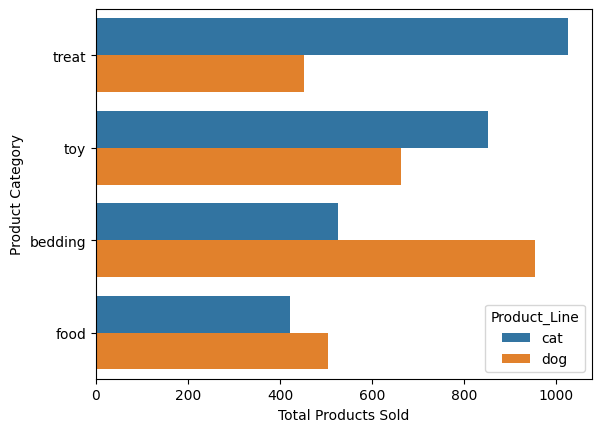

In [39]:
# Creating a horizontal bar plot that meets the question requirements.
ax = sns.barplot(data=df, y='Product_Category', x='Quantity', estimator=sum, ci=None, hue='Product_Line')

# Setting a meaningful title and labels.
ax.set_ylabel('Product Category')
ax.set_xlabel ('Total Products Sold')
ax.set_title = ('Total Number of Products Sold')


### Question 9: Based on the plot from Question 8, what would you conclude for your stakeholders about what products they should sell? What would be the considerations and/or caveats you'd communicate to your stakeholders?

In [ ]:
answer_to_9 = '''
Based on the visualization, I would advise stakeholders to focus on treats for cats and bedding for dogs, as these appear to be the most popular products within their respective product lines, with toys also performing well. However, it's important to note that this analysis is based on a single dataset, which may not be the most up-to-date or account for seasonal trends.
'''

### Question 10: Create an explanatory visualization that gives business stakeholders deeper insights into product sales trends.

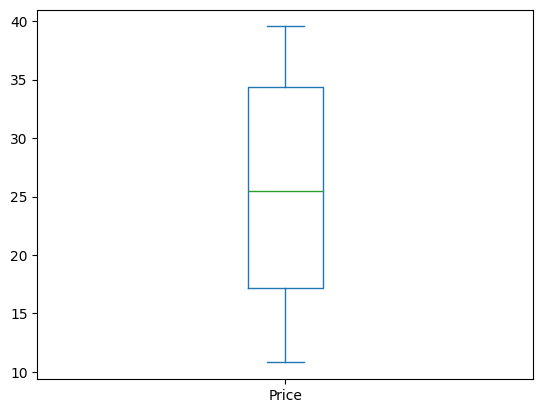

In [44]:
# Creating a box plot
ax = df.Price.plot.box()

answer_to_10 = '''
I created a box plot to illustrate the distribution of product prices. The plot reveals that most product prices fall between approximately $17 and $35, with some notable outliers—prices as high as around $40 and as low as $11 or $12. This visualization not only highlights the central tendency and variability in pricing but also helps stakeholders understand the overall price range of the products. Such insights can inform pricing strategies, inventory decisions, and identify opportunities for adjustments to maximize revenue.
'''